# Uniform Sampling on an Infinite Domain

In [1]:
import numpy as np

In [2]:
import os
import sys
from datetime import datetime

from importlib import reload
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utils')
os.chdir(current_dir)
if utilities_dir not in sys.path:
    sys.path.insert(0, utilities_dir)
import plotting
import pinns_infinite
import infinite
reload(plotting)
reload(pinns_infinite)
reload(infinite)
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
import torch.optim as optim
from pinns_infinite import  MLP, init_weights, CoefficientNet, pde_loss_inf, observation_loss_u, observation_loss_k, train_dual_network, build_models, set_seed,run_experiment_inf,build_models_KAN
from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)
from plotting import plot_histories_comparison

set_seed(42)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

/home/orincon/miniconda3/envs/PIKAN-unbounded-domains-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate uniform observations and evaluation data

In [3]:
(
    X_obs,
    U_obs,
    X_obs_k,
    K_obs,
    X_pde,
    F_pde,
    X,
    Y,
    U,
    K,
) = generate_dataset_inf(
    sigma=0.0,
    sampling="uniform",
    n_obs_u=100,
    n_obs_k=100,
    n_pde=1000,
    plot=False,
    device=device,
    seed=42,
)

## Load the trained KAN models

In [4]:
checkpoint_path = os.path.join(
    "..", "03_individual_prediction", "results", "pikan_infinite_uniform_weights.pt"
)
checkpoint = torch.load(checkpoint_path, map_location=device)
saved_config = checkpoint["config"]

model_u, model_k = build_models_KAN(
    device,
    hidden_layers=saved_config["hidden_layers"],
    hidden_units=saved_config["hidden_units"],
    grid_size=saved_config["grid_size"],
    spline_order=saved_config["spline_order"],
)

model_u.load_state_dict(checkpoint["model_u"])
model_k.load_state_dict(checkpoint["model_k"])
model_u.eval()
model_k.eval()

print(f"Loaded model from: {checkpoint_path}")
print(f"Stored mean global error: {checkpoint['metrics']['err_mean_global']:.6e}")


Loaded model from: ../03_individual_prediction/results/pikan_infinite_uniform_weights.pt
Stored mean global error: 3.758214e-02


## Evaluate spatial generalization and create the figure

In [5]:
reload(infinite)

from infinite import analytical_solution_inf, coefficient_inf, source_term_inf, generate_dataset_inf, evaluate_model_inf
torch.set_default_dtype(torch.float32)


Spatial generalization (MAE)
Training domain : [-5, 5] × [-5, 5]
Evaluation domain : [-10, 10] × [-10, 10]

Global MAE
u : 1.066e-02
k : 6.451e-02

Inside training domain
u : 1.868e-03
k : 6.165e-04

Outside training domain
u : 1.359e-02
k : 8.580e-02
Maximum |u_hat - u|: 0.359375
Maximum |k_hat - k|: 0.593349
Prediction plot saved to: figures/uniform_infinite.pdf


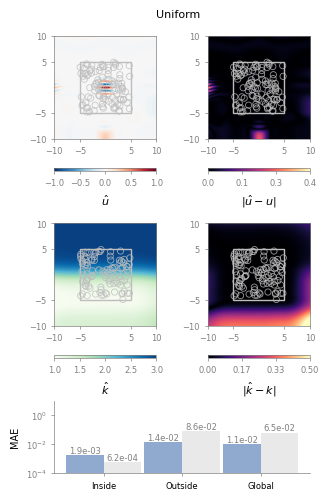

In [6]:
results = evaluate_model_inf(
    model_u=model_u,
    model_k=model_k,

    analytical_solution=analytical_solution_inf,
    coefficient=coefficient_inf,

    X_obs=X_obs,
    X_obs_k=X_obs_k,

    sampling="Uniform",

    # Training domain
    train_xmin=-5,
    train_xmax=5,
    train_ymin=-5,
    train_ymax=5,

     
    eval_xmin=-10,
    eval_xmax=10,
    eval_ymin=-10,
    eval_ymax=10,

    n_grid=400,

    alpha=0.5,
    beta=5.0,
    epsilon=1.0,

    device=device,

    plot=True,
    show_bar_ylabel=True,
    show_legend=False,
    verbose=True,

    save_results=False,
    results_dir="results",

    save_plot=True,
    plot_path="figures/uniform_infinite.pdf",
)